In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [59]:
df=pd.read_csv("test_predictions_8.csv")

In [60]:
df['ID']=df['ID'].str.replace('/data/lautaro/quasiraw_ext/','')
#si ID contiene RRIB, entonces df dataset = 'RRIB', si contiene RRI, entonces df dataset = 'RRI', sino df dataset = 'Other'
df['dataset'] = np.where(df['ID'].str.contains('RRIB'), 'RRIB', np.where(df['ID'].str.contains('_S_'), 'ADNI', np.where(df['ID'].str.contains('CP'), 'UNSAM_LC',  np.where(df['ID'].str.contains('JUK'), 'JUK', 'Other'))))

In [61]:
#MAE por dataset
df.groupby('dataset')['Absolute Error'].mean().reset_index()

,dataset,Absolute Error
0,ADNI,5.758164
1,JUK,7.794536
2,RRIB,9.002746
3,UNSAM_LC,6.899335


In [62]:
df['Absolute Error'].mean()

np.float64(6.390592378996467)

C:\Users\Admin\AppData\Local\Temp\ipykernel_10620\3943514063.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.scatterplot(data=df, y='Age', x='Prediction', hue='dataset', palette=['red', 'blue', 'green', 'orange', 'purple'])


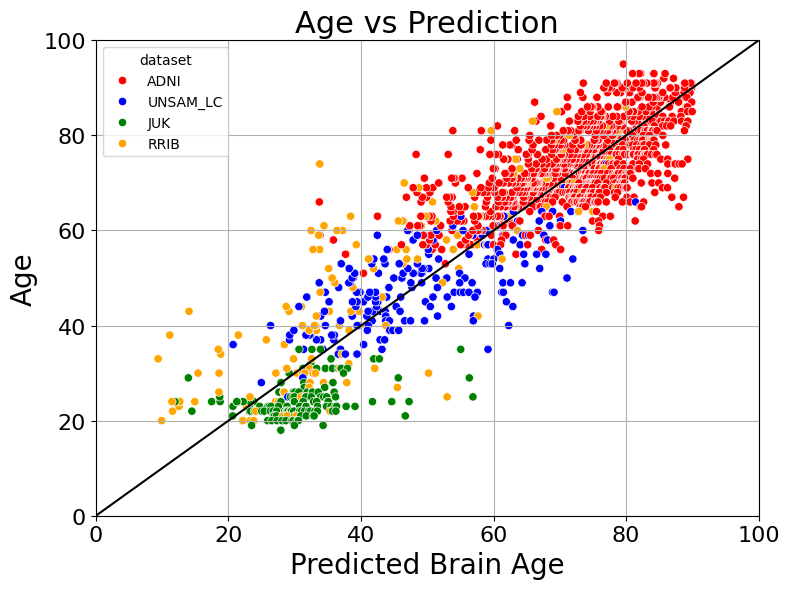

6.390592378996467


In [66]:
plt.figure(figsize=(8, 6))
#un color distinto por cada dataset
sns.scatterplot(data=df, y='Age', x='Prediction', hue='dataset', palette=['red', 'blue', 'green', 'orange', 'purple'])

plt.plot([0, 100], [0, 100], color='black')
plt.title('Age vs Prediction', fontsize=22)
plt.xlabel('Predicted Brain Age', fontsize=20)
plt.ylabel('Age', fontsize=20)

plt.grid(True)

plt.xlim(0, 100)
plt.ylim(0, 100)
plt.tick_params(axis='both', labelsize=16)  # Cambia 16 por el tamaño que prefieras

plt.tight_layout()
plt.show()
print(df['Absolute Error'].mean())

In [64]:
vit_UNSAM=df[df['dataset']=='UNSAM_LC']
vit_ADNI=df[df['dataset']=='ADNI']
vit_RRIB=df[df['dataset']=='RRIB']
vit_JUK=df[df['dataset']=='JUK']
vit_other=df[df['dataset']=='Other']

vit_UNSAM['mean']=(vit_UNSAM['Age']+vit_UNSAM['Prediction'])/2
vit_ADNI['mean']=(vit_ADNI['Age']+vit_ADNI['Prediction'])/2
vit_RRIB['mean']=(vit_RRIB['Age']+vit_RRIB['Prediction'])/2
vit_JUK['mean']=(vit_JUK['Age']+vit_JUK['Prediction'])/2
vit_other['mean']=(vit_other['Age']+vit_other['Prediction'])/2
df['mean']=(df['Age']+df['Prediction'])/2

mean_diff_vit=np.mean(df['Error'])
std_diff_vit=np.std(df['Error'])
#intervalo de confianza del 95%
upper_limit_vit = mean_diff_vit + 1.96 * std_diff_vit
lower_limit_vit = mean_diff_vit - 1.96 * std_diff_vit


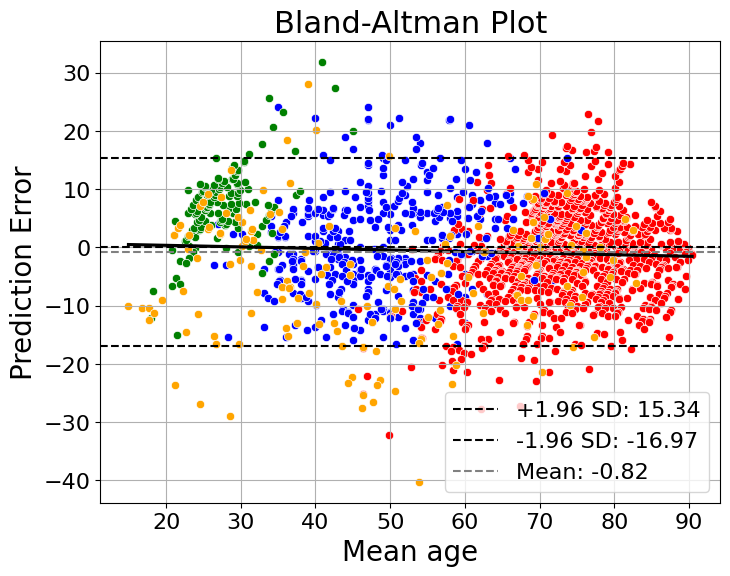

In [67]:
# -- Error en funcion de Age --
plt.figure(figsize=(8, 6))
sns.scatterplot(data=vit_UNSAM, x='Age', y='Error', color='blue')
sns.scatterplot(data=vit_other, x='Age', y='Error', color='purple')
sns.scatterplot(data=vit_ADNI, x='mean', y='Error', color='red')
sns.scatterplot( data=vit_UNSAM, x='mean', y='Error', color='blue')
sns.regplot( data=df, x='mean', y='Error', scatter=False, color='black', ci=None)
sns.scatterplot(data=vit_JUK, x='mean', y='Error', color='green')
sns.scatterplot( data=vit_RRIB, x='mean', y='Error', color='orange')
#grafico de upper y lower limit
plt.axhline(upper_limit_vit, color='black', linestyle='--',label=f'+1.96 SD: {upper_limit_vit:.2f}')
plt.axhline(lower_limit_vit, color='black', linestyle='--', label=f'-1.96 SD: {lower_limit_vit:.2f}')
plt.axhline(mean_diff_vit, color='gray', linestyle='--', label=f'Mean: {mean_diff_vit:.2f}')
plt.xlabel('Mean age',fontsize=20)
plt.legend(fontsize=16)
plt.axhline(0, color='black', linestyle='--')
plt.title('Bland-Altman Plot', fontsize=22)
plt.ylabel('Prediction Error', fontsize=20)
plt.grid(True)
plt.tick_params(axis='both', labelsize=16)  # Cambia 16 por el tamaño que prefieras
plt.show()